/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 - mae: 0.0548  
✅ Pérdida en test (MSE): 0.004985
📏 MAE (Error absoluto medio): 0.056470


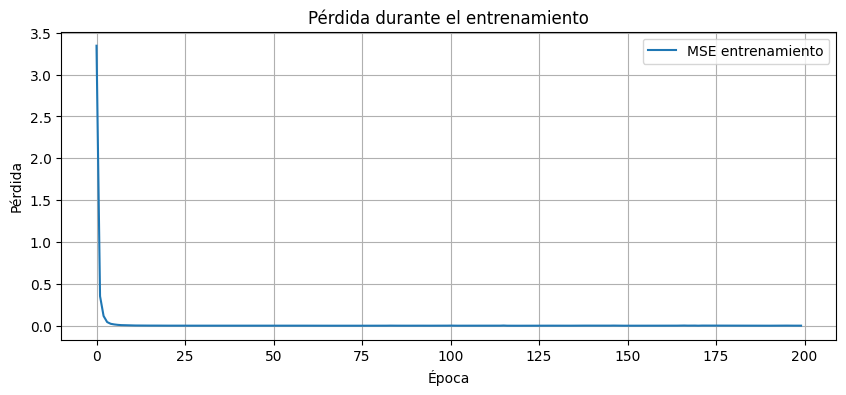

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


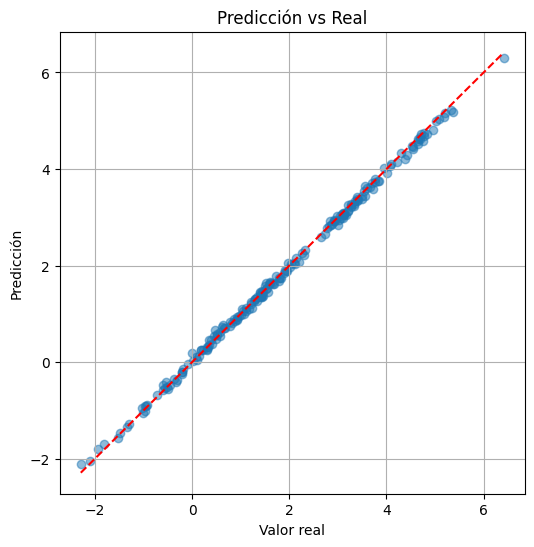

In [1]:
# Paso 1: Importar librerías necesarias
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Paso 2: Generar datos sintéticos
np.random.seed(42)
n = 1000
X1 = np.random.rand(n)
X2 = np.random.rand(n)
X3 = np.random.rand(n)

# Crear relación lineal exacta con poco ruido
Y = 5 * X1 - 3 * X2 + 2 * X3 + np.random.normal(0, 0.05, n)

X = np.stack((X1, X2, X3), axis=1)

# Paso 3: Dividir y normalizar
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Paso 4: Definir modelo de red neuronal más robusto
modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)  # salida lineal
])

modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                loss='mse', metrics=['mae'])

# Paso 5: Entrenar modelo
historial = modelo.fit(X_train, y_train, epochs=200, verbose=0)

# Paso 6: Evaluar el modelo
loss, mae = modelo.evaluate(X_test, y_test)
print(f"✅ Pérdida en test (MSE): {loss:.6f}")
print(f"📏 MAE (Error absoluto medio): {mae:.6f}")

# Paso 7: Graficar pérdida
plt.figure(figsize=(10,4))
plt.plot(historial.history['loss'], label="MSE entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

# Paso 8: Comparar reales vs predichos
y_pred = modelo.predict(X_test).flatten()
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.grid(True)
plt.show()